In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simulate_vp(x0, lambda_c, T, n_steps, n_paths, seed):
    rng = np.random.default_rng(seed)
    t = np.linspace(0.0, T, n_steps + 1)
    dt = t[1] - t[0]

    sigma = np.sqrt(2 * lambda_c)

    decay = np.exp(-lambda_c * dt)
    step_var = 1 - np.exp(-2 * lambda_c * dt)
    step_std = np.sqrt(step_var)

    X = np.empty((n_paths, n_steps + 1))
    X[:, 0] = x0

    for k in range(n_steps):
        noise = rng.standard_normal(n_paths)
        X[:, k + 1] = X[:, k] * decay + step_std * noise
    return t, X

def vp_theoretical_mean_std(t, x0, lambda_c):
    mean_t = x0  * np.exp(-lambda_c * t)
    var_t = 1 - np.exp(-2 * lambda_c * t)
    var_t = np.clip(var_t, 0.0, None)
    return mean_t, np.sqrt(var_t)


def plot_vp(t, X, x0, lambda_c, save_path):
    empirical_mean = X.mean(axis=0)
    empirical_std = X.std(axis=0)
    theo_mean, theo_std = vp_theoretical_mean_std(t, x0, lambda_c)

    fig, ax = plt.subplots(figsize=(9, 6))

    for path in X:
        ax.plot(t, path, linewidth=0.8, alpha=0.5)

    ax.plot(t, theo_mean, color="black", linestyle="-", linewidth=1.5,
            label="theoretical mean")
    ax.plot(t, theo_mean + 2*theo_std, color="green", linestyle="-", linewidth=1.5,
            label="theoretical mean ± 2*std")
    ax.plot(t, theo_mean - 2*theo_std, color="green", linestyle="-", linewidth=1.5,)

    ax.plot(t, empirical_mean, color="blue", linestyle="--", linewidth=1.5,
            label="empirical mean")
    ax.plot(t, empirical_mean + 2 * empirical_std, color="red", linestyle="--",
            linewidth=1.5, label="empirical mean ± 2*std")
    ax.plot(t, empirical_mean - 2 * empirical_std, color="red", linestyle="--",
            linewidth=1.5)

    ax.set_title("Variance Preserving")
    ax.set_xlabel("$\\tau$")
    ax.set_ylabel("$x(\\tau)$")
    ax.legend(loc="upper left")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)

In [3]:
def simulate_ve(x0, sigma, T, n_steps, n_paths, seed):

    rng = np.random.default_rng(seed)
    t = np.linspace(0.0, T, n_steps + 1)
    dt = t[1] - t[0]

    X = np.empty((n_paths, n_steps + 1))
    X[:, 0] = x0
    std_t = sigma * np.sqrt(dt)
    for k in range(n_steps):
        noise = rng.standard_normal(n_paths)
        X[:, k + 1] = X[:, k] + std_t * noise

    return t, X


def plot_ve(t, X, sigma, x0, save_path):
    empirical_mean = X.mean(axis=0)
    empirical_std = X.std(axis=0)
    theo_mean = np.full_like(t, x0)

    std_t = sigma * np.sqrt(t)

    fig, ax = plt.subplots(figsize=(9, 6))

    for path in X:
        ax.plot(t, path, linewidth=0.8, alpha=0.5)

    ax.plot(t, theo_mean, color="black", linestyle="-", linewidth=1.5,
            label="theoretical mean")
    ax.plot(t, theo_mean + 2*std_t, color="green", linestyle="-", linewidth=1.5,
            label="theoretical mean ± 2*std")
    ax.plot(t, theo_mean - 2*std_t, color="green", linestyle="-", linewidth=1.5,
            )

    ax.plot(t, empirical_mean, color="blue", linestyle="--", linewidth=1.5,
            label="empirical mean")
    ax.plot(t, empirical_mean + 2 * empirical_std, color="red", linestyle="--",
            linewidth=1.5, label="empirical mean ± 2*std")
    ax.plot(t, empirical_mean - 2 * empirical_std, color="red", linestyle="--",
            linewidth=1.5)

    ax.set_title("Variance Exploding")
    ax.set_xlabel("$\\tau$")
    ax.set_ylabel("$x(\\tau)$")
    ax.legend(loc="upper left")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)

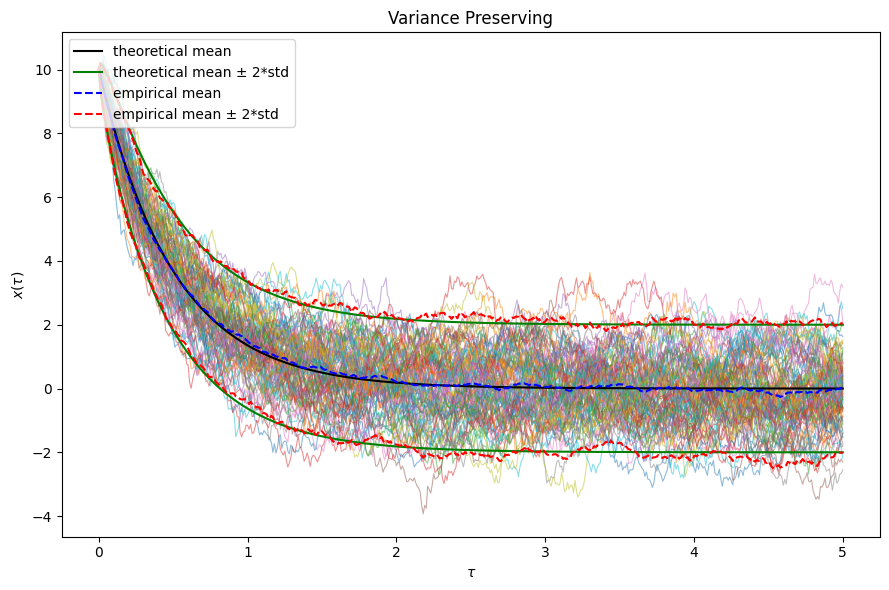

In [4]:
x_0 = 10.0
N = 100
n_steps = 500
T = 5.0
seed = 0

lambda_c = 2.0
t_vp, X_vp = simulate_vp(x0=x_0, lambda_c=lambda_c, T=T, n_steps=n_steps, n_paths=N, seed=seed)
plot_vp(t_vp, X_vp, x0=x_0, lambda_c=lambda_c, save_path="vp_ou_simulation.pdf")

Saved vp_ou_simulation.pdf and ve_sde_simulation.pdf


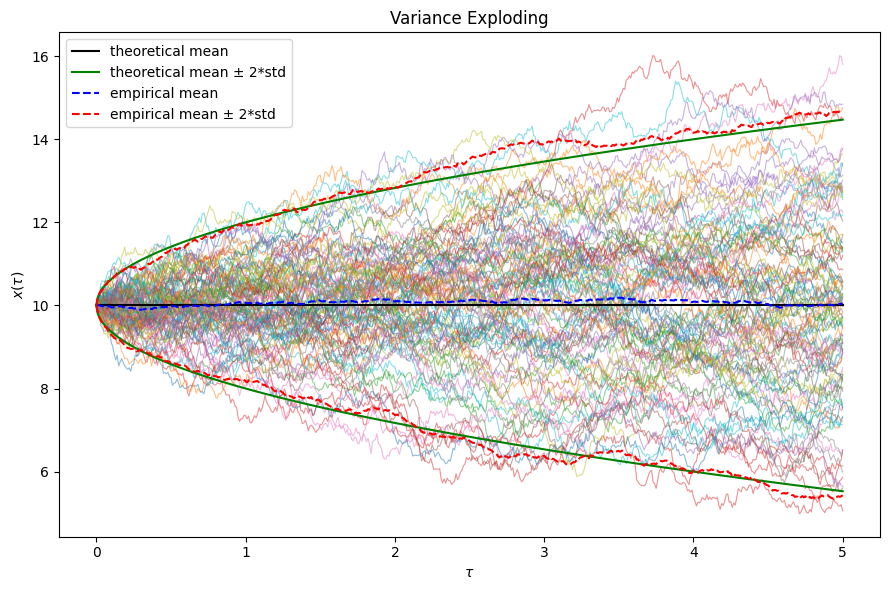

In [5]:
sigma = 1.0
t_ve, X_ve = simulate_ve(x0=x_0, sigma=sigma, T=T, n_steps=n_steps, n_paths=N, seed=seed)
plot_ve(t_ve, X_ve, x0=x_0, sigma=sigma, save_path="ve_sde_simulation.pdf")

print("Saved vp_ou_simulation.pdf and ve_sde_simulation.pdf")